# Conditional GAN - MNIST

Make Your First GAN With PyTorch, 2020

In [1]:
# import libraries

import torch
import torch.nn as nn
from torchvision import datasets, transforms

import pandas, numpy, random
import matplotlib.pyplot as plt

In [30]:
# Use GPU if available, otherwise stick with cpu
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(device)

cuda:1


## Dataset Class

In [2]:
mnist_dataset = datasets.MNIST('/data/datasets',  train=True, download=True, 
                                transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=(0.5,), std=(0.5,))]))        

tensor(3)

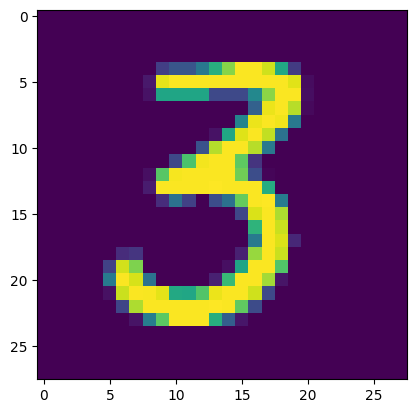

In [5]:
# 查看其中任意一个样本
idx = 767
plt.imshow(mnist_dataset.data[idx,:,:].numpy())
mnist_dataset.targets[idx]

## Data Functions

In [5]:
# functions to generate random data

def generate_random_image(size):
    random_data = torch.rand(size)
    return random_data


def generate_random_seed(size):
    random_data = torch.randn(size)
    return random_data

# size here must only be an integer
def generate_random_one_hot(size):
    label_tensor = torch.zeros((size))
    random_idx = random.randint(0,size-1)
    label_tensor[random_idx] = 1.0
    return label_tensor

## Discriminator Network

In [50]:
# discriminator class

class Discriminator(nn.Module):
    
    def __init__(self):
        # initialise parent pytorch class
        super().__init__()
        
        # define neural network layers
        self.model = nn.Sequential(
        #    nn.Linear(784+10, 200), nn.LeakyReLU(0.02), nn.LayerNorm(200),
         #   nn.Linear(400, 200), nn.LeakyReLU(0.2), nn.LayerNorm(200),
        #    nn.Linear(200, 1),      nn.Sigmoid() )
            nn.Linear(784+10, 512), nn.LeakyReLU(0.2), nn.LayerNorm(512),
            nn.Linear(512, 256), nn.LeakyReLU(0.2), nn.LayerNorm(256),
            nn.Linear(256, 1),   nn.Sigmoid() )
        
        # create loss function
        self.loss_function = nn.BCELoss()

        # create optimiser, simple stochastic gradient descent
        self.optimiser = torch.optim.Adam(self.parameters(), lr=0.0001)

        # counter and accumulator for progress
        self.counter = 1;
        self.progress = []

        pass
    
    
    def forward(self, image_tensor, label_tensor):
        # combine seed and label
        inputs = torch.cat((image_tensor, label_tensor))
        return self.model(inputs)
    
    
    def train(self, inputs, label_tensor, targets):
        # calculate the output of the network
        outputs = self.forward(inputs, label_tensor)
        
        # calculate loss
        loss = self.loss_function(outputs, targets)

        # increase counter and accumulate error every 10
        self.counter += 1;
        if (self.counter % 10 == 0):
            self.progress.append(loss.item())
            pass
        if (self.counter % 10000 == 0):
            print("counter = ", self.counter)
            pass

        # zero gradients, perform a backward pass, update weights
        self.optimiser.zero_grad()
        loss.backward()
        self.optimiser.step()

        pass
    
    
#    def plot_progress(self):
#        df = pandas.DataFrame(self.progress, columns=['loss'])
#        df.plot(ylim=(0), figsize=(16,8), alpha=0.1, marker='.', grid=True, yticks=(0, 0.25, 0.5, 1.0, 5.0))
#        pass
    
    pass

## Test Discriminator

In [51]:
%%time
# test discriminator can separate real data from random noise

D = Discriminator() # .to(device)
idx = 1
for img, label_idx in mnist_dataset:
    if idx == 500:    # only do batch_idx times
        break
    idx += 1
    label_tensor = torch.zeros((10))
    label_tensor[label_idx] = 1.0
    # real data
    D.train(img.reshape(784), label_tensor, torch.FloatTensor([1.0]))
 #   D.train(img.reshape(784).to(device), label_tensor.to(device), torch.FloatTensor([1.0]).to(device))
    # fake data
    D.train(generate_random_image(784), generate_random_one_hot(10), torch.FloatTensor([0.0]))
#    D.train(generate_random_image(784).to(device), generate_random_one_hot(10).to(device), torch.FloatTensor([0.0]).to(device))
    pass

CPU times: user 1min 43s, sys: 2.47 s, total: 1min 45s
Wall time: 5.71 s


<Axes: >

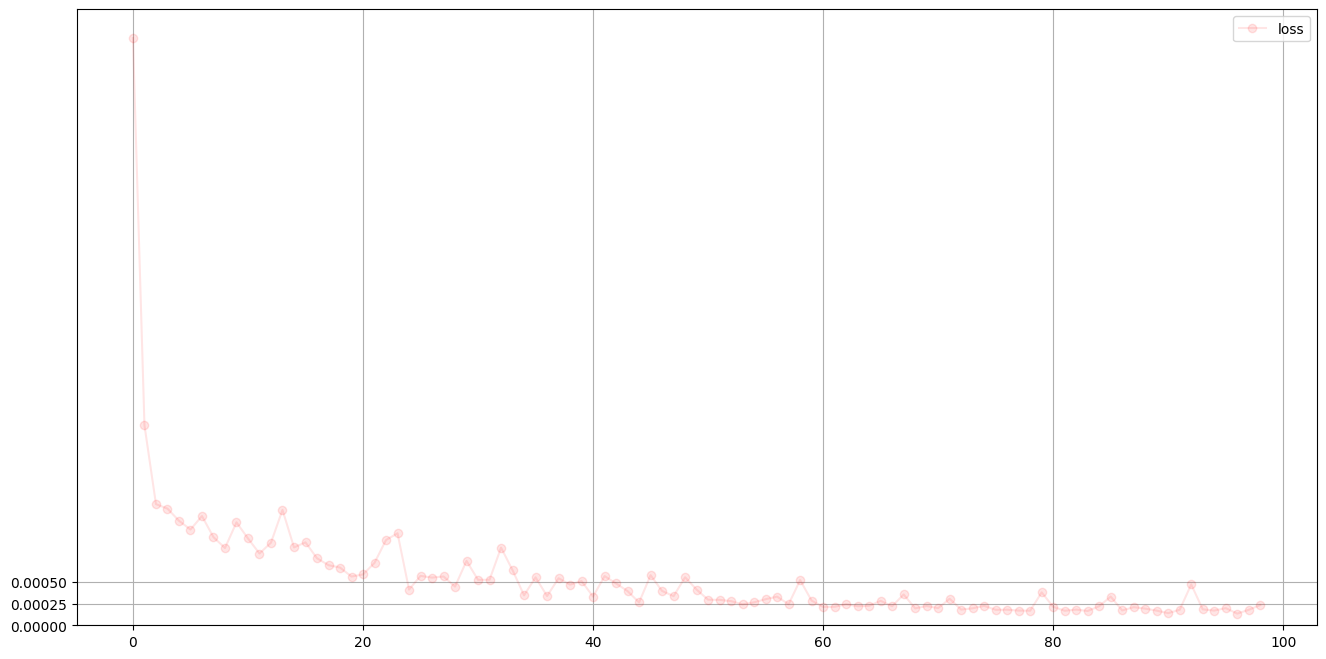

In [52]:
# plot discriminator loss    # D.plot_progress()
# D = D.to('cpu')
df = pandas.DataFrame(D.progress, columns=['loss'])
df.plot(ylim=(0), figsize=(16,8), alpha=0.1, marker='o', colormap='prism', grid=True, yticks=(0, 0.00025, 0.0005))

## Generator Network

In [53]:
# generator class

class Generator(nn.Module):
    
    def __init__(self):
        # initialise parent pytorch class
        super().__init__()
        
        # define neural network layers
        self.model = nn.Sequential(
     #       nn.Linear(100+10, 200),      nn.LeakyReLU(0.02),       nn.LayerNorm(200),
     #       nn.Linear(200, 784),         nn.Sigmoid()                       # a small generator, takes 2.5 hrs with 16 core cpu
            nn.Linear(100+10, 256), nn.LeakyReLU(0.2), nn.LayerNorm(256),
            nn.Linear(256, 512), nn.LeakyReLU(0.2), nn.LayerNorm(512),
            nn.Linear(512, 1024), nn.LeakyReLU(0.2), nn.LayerNorm(1024),
            nn.Linear(1024, 784), nn.Tanh()
        )
        
        # create optimiser, simple stochastic gradient descent
        self.optimiser = torch.optim.Adam(self.parameters(), lr=0.0001)

        # counter and accumulator for progress
        self.counter = 1;
        self.progress = []
        
        pass
    
    
    def forward(self, seed_tensor, label_tensor):        
        # combine seed and label
        inputs = torch.cat((seed_tensor, label_tensor))
        return self.model(inputs)


    def train(self, D, inputs, label_tensor, targets):
        # calculate the output of the network
        g_output = self.forward(inputs, label_tensor)
        
        # pass onto Discriminator
        d_output = D.forward(g_output, label_tensor)
        
        # calculate error
        loss = D.loss_function(d_output, targets)

        # increase counter and accumulate error every 10
        self.counter += 1;
        if (self.counter % 10 == 0):
            self.progress.append(loss.item())
            pass

        # zero gradients, perform a backward pass, update weights
        self.optimiser.zero_grad()
        loss.backward()
        self.optimiser.step()

        pass
    
    def plot_images(self, label):
        label_tensor = torch.zeros((10))
        label_tensor[label] = 1.0
        # plot a 3 column, 2 row array of sample images
        f, axarr = plt.subplots(2,3, figsize=(16,8))
        for i in range(2):
            for j in range(3):
                axarr[i,j].imshow(G.forward(generate_random_seed(100), label_tensor).detach().cpu().numpy().reshape(28,28), interpolation='none', cmap='Blues')
                pass
            pass
        pass
    
    def plot_progress(self):
        df = pandas.DataFrame(self.progress, columns=['loss'])
        df.plot(ylim=(0), figsize=(16,8), alpha=0.1, marker='.', grid=True, yticks=(0, 0.25, 0.5, 1.0, 5.0))
        pass
    
    pass

## Test Generator Output

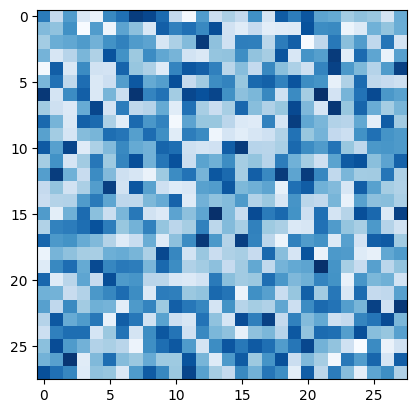

In [54]:
# check the generator output is of the right type and shape

G = Generator()

output = G.forward(generate_random_seed(100), generate_random_one_hot(10))

img = output.detach().numpy().reshape(28,28)

plt.imshow(img, interpolation='none', cmap='Blues')

## Train GAN

In [55]:
# create Discriminator and Generator

D = Discriminator()
G = Generator()

In [56]:
%%time 

epochs = 10

for epoch in range(epochs):
  print ("epoch = ", epoch + 1)

  # train Discriminator and Generator

  idx = 1
  for img, label_idx in mnist_dataset:
    if idx == 50000:    # only do batch_idx times
      break
    idx += 1
    
    # real data
    label_tensor = torch.zeros((10))
    label_tensor[label_idx] = 1.0
    D.train(img.reshape(784), label_tensor, torch.FloatTensor([1.0]))

    
    # train discriminator on false
    # random 1-hot label for generator
    random_label = generate_random_one_hot(10)
    # use detach() so gradients in G are not calculated
    D.train(G.forward(generate_random_seed(100), random_label).detach(), random_label, torch.FloatTensor([0.0]))
    
    # different random 1-hot label for generator
    random_label = generate_random_one_hot(10)

    # train generator
    G.train(D, generate_random_seed(100), random_label, torch.FloatTensor([1.0]))

    pass
    
  pass

epoch =  1
counter =  10000
counter =  20000
counter =  30000
counter =  40000
counter =  50000
counter =  60000
counter =  70000
counter =  80000
counter =  90000
epoch =  2
counter =  100000
counter =  110000
counter =  120000
counter =  130000
counter =  140000
counter =  150000
counter =  160000
counter =  170000
counter =  180000
counter =  190000
epoch =  3
counter =  200000
counter =  210000
counter =  220000
counter =  230000
counter =  240000
counter =  250000
counter =  260000
counter =  270000
counter =  280000
counter =  290000
epoch =  4
counter =  300000
counter =  310000
counter =  320000
counter =  330000
counter =  340000
counter =  350000
counter =  360000
counter =  370000
counter =  380000
counter =  390000
epoch =  5
counter =  400000
counter =  410000
counter =  420000
counter =  430000
counter =  440000
counter =  450000
counter =  460000
counter =  470000
counter =  480000
counter =  490000
epoch =  6
counter =  500000
counter =  510000
counter =  520000
counter

#### test performance on 2022 with 10 epoch
CPU times: user 2d 12h 42min 39s, sys: 1h 26min 49s, total: 2d 14h 9min 29s
Wall time: 3h 28min 31s

<Axes: >

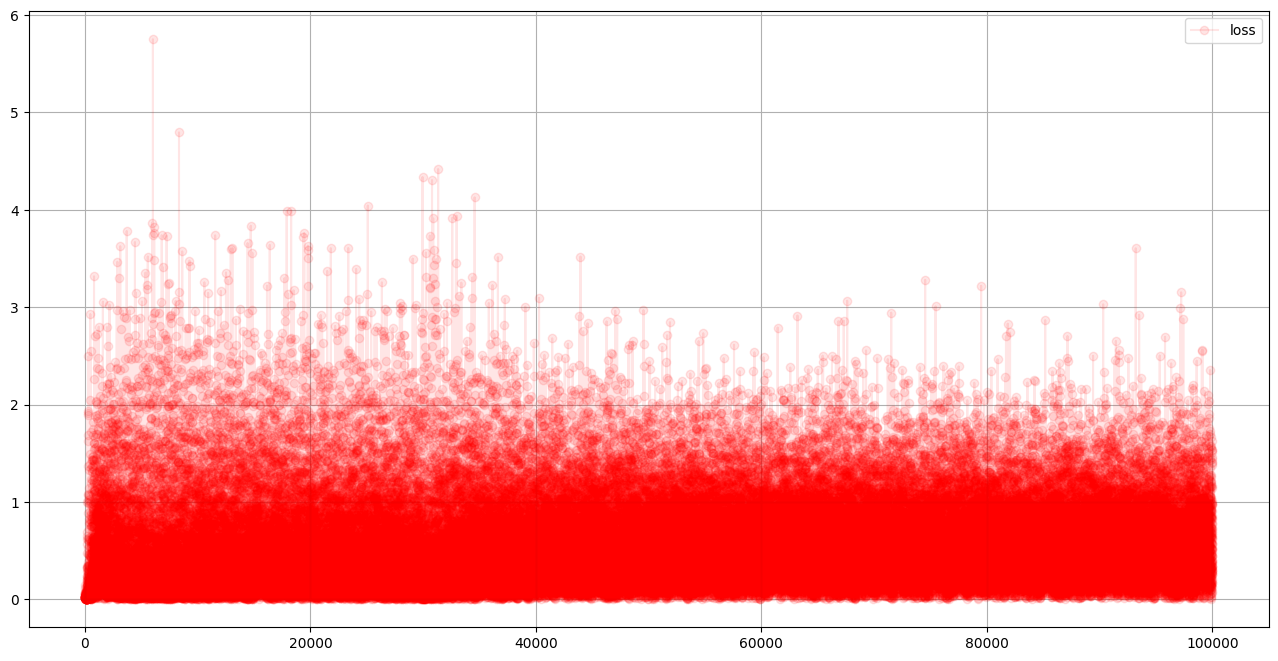

In [64]:
# plot discriminator error
df = pandas.DataFrame(D.progress, columns=['loss'])
df.plot(figsize=(16,8), alpha=0.1, marker='o', colormap='prism', grid=True)

<Axes: >

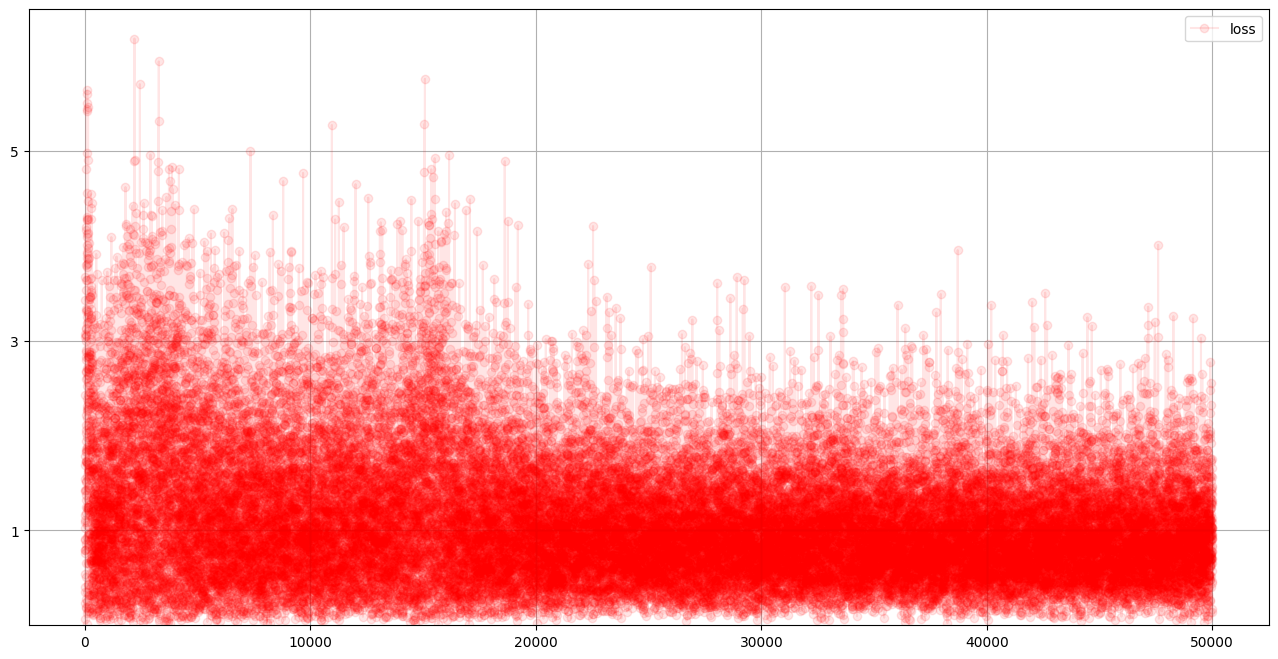

In [63]:
# plot generator error
df = pandas.DataFrame(G.progress, columns=['loss'])
df.plot(ylim=(0), figsize=(16,8), alpha=0.1, marker='o', colormap='prism', grid=True, yticks=(1,3,5))

## Run Generator

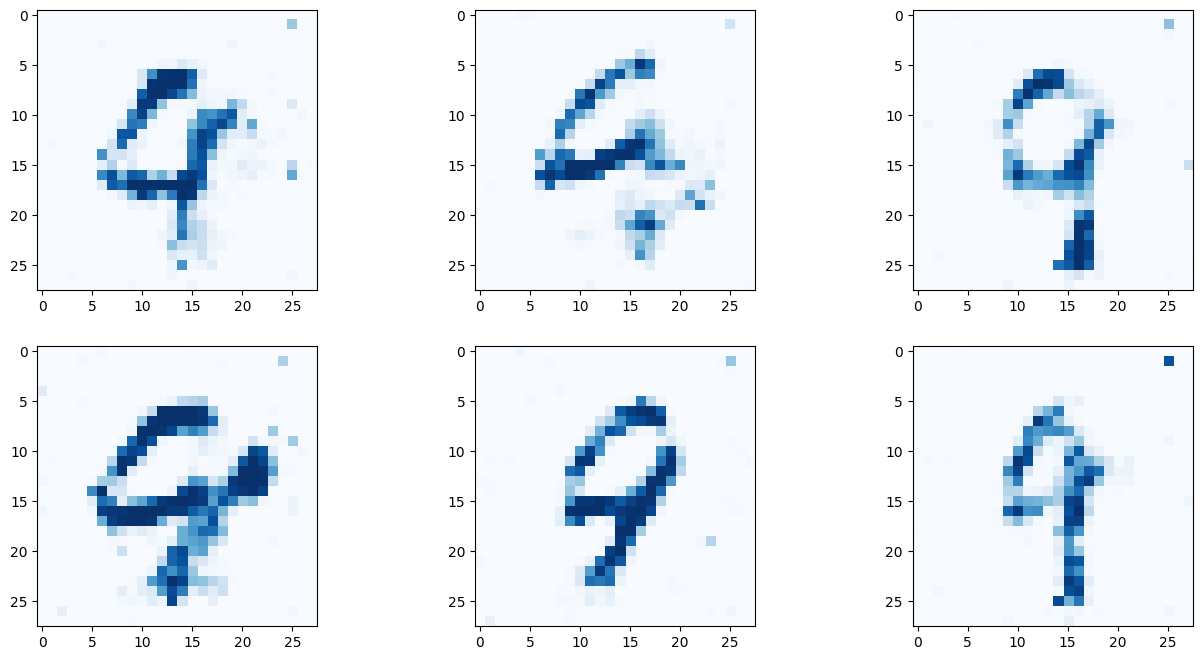

In [59]:
# plot several outputs from the trained generator
G.plot_images(9)

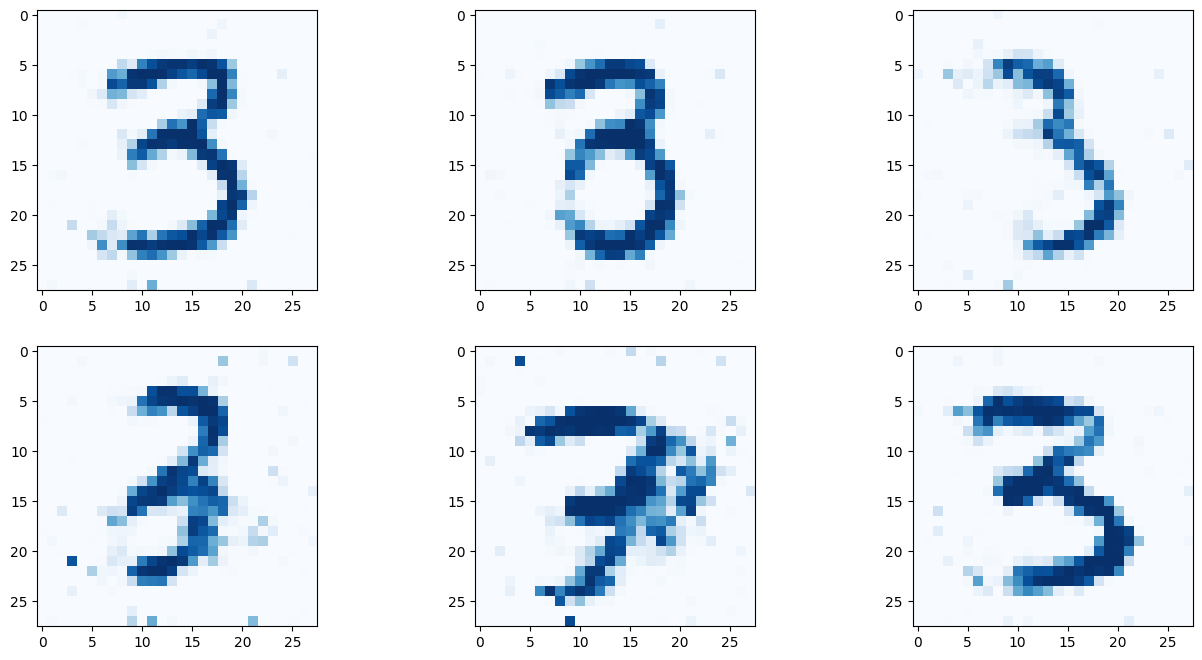

In [60]:
# plot several outputs from the trained generator

G.plot_images(3)

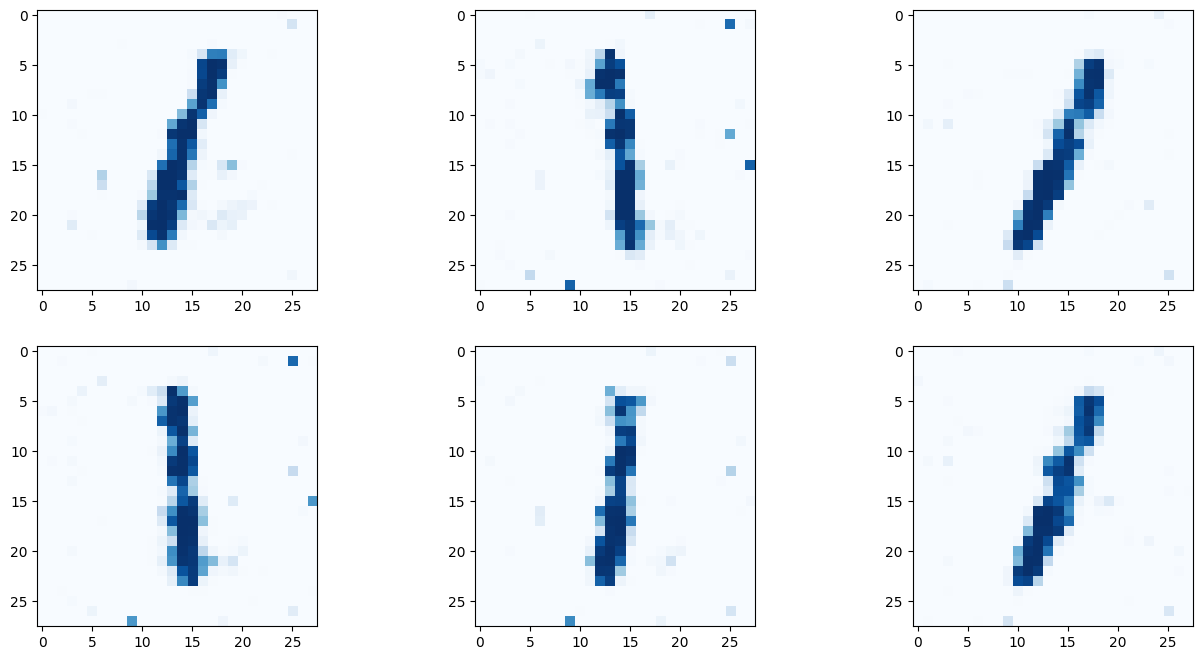

In [62]:
# plot several outputs from the trained generator
G.plot_images(1)

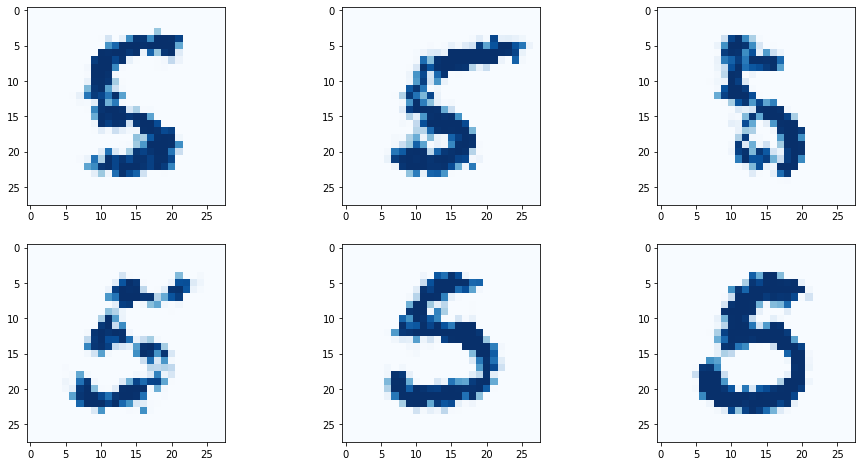

In [ ]:
# plot several outputs from the trained generator

G.plot_images(5)

### 基于预训练DCGAN展示生成

In [14]:
import matplotlib.pyplot as plt
import torchvision
import torch

In [12]:
model = torch.hub.load("facebookresearch/pytorch_GAN_zoo:hub", "DCGAN",  pretrained=True, useGPU=True)

Downloading: "https://github.com/facebookresearch/pytorch_GAN_zoo/zipball/hub" to /home/imath/.cache/torch/hub/hub.zip
Downloading: "https://dl.fbaipublicfiles.com/gan_zoo/DCGAN_fashionGen-1d67302.pth" to /home/imath/.cache/torch/hub/checkpoints/DCGAN_fashionGen-1d67302.pth


  0%|          | 0.00/39.7M [00:00<?, ?B/s]

Average network found !


In [15]:
#随机生成噪声
(noise, _) = model.buildNoiseData(64)
with torch.no_grad():
	generatedImages = model.test(noise)

In [16]:
output = torchvision.utils.make_grid(generatedImages).permute(1, 2, 0).cpu().numpy()

In [21]:
output

array([[[          0,           0,           0],
        [          0,           0,           0],
        [          0,           0,           0],
        ...,
        [          0,           0,           0],
        [          0,           0,           0],
        [          0,           0,           0]],

       [[          0,           0,           0],
        [          0,           0,           0],
        [          0,           0,           0],
        ...,
        [          0,           0,           0],
        [          0,           0,           0],
        [          0,           0,           0]],

       [[          0,           0,           0],
        [          0,           0,           0],
        [    0.99994,     0.99997,     0.99998],
        ...,
        [    0.99989,     0.99989,     0.99992],
        [          0,           0,           0],
        [          0,           0,           0]],

       ...,

       [[          0,           0,           0],
        [  

In [19]:
plt.imshow(output)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


In [20]:
plt.show()